Saving TicoShop_Clientes.xlsx to TicoShop_Clientes (32).xlsx
Archivo cargado correctamente
Cantidad de clientes: 2000

Primeras filas:
  cliente_id  recencia  frecuencia   monto  antiguedad_meses  quejas  usa_app  \
0      C0001        26          10  217500                35       0        0   
1      C0002        33           5  346900                 5       0        1   
2      C0003        54           8  212800                29       0        0   
3      C0004        17           2  116800                 1       0        0   
4      C0005        62          10  118300                40       0        0   

   se_fue  
0       0  
1       0  
2       0  
3       0  
4       0  

Clientes que se fueron y se quedaron:
se_fue
0    1570
1     430
Name: count, dtype: int64

Porcentaje de abandono:
se_fue
0    78.5
1    21.5
Name: proportion, dtype: float64

Promedios segun estado del cliente:
          recencia  frecuencia          monto  antiguedad_meses    quejas  \
se_fue         

<Figure size 700x500 with 0 Axes>

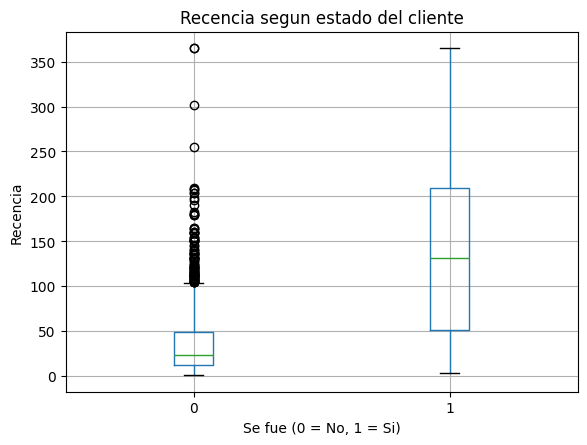

<Figure size 700x500 with 0 Axes>

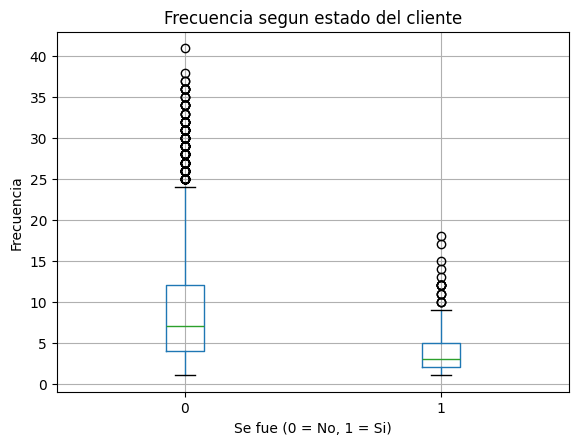

<Figure size 700x500 with 0 Axes>

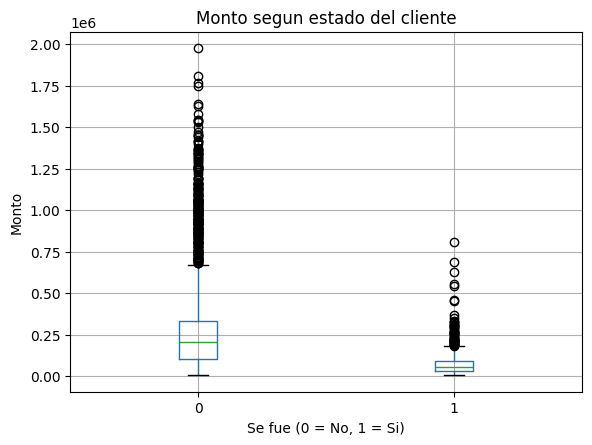

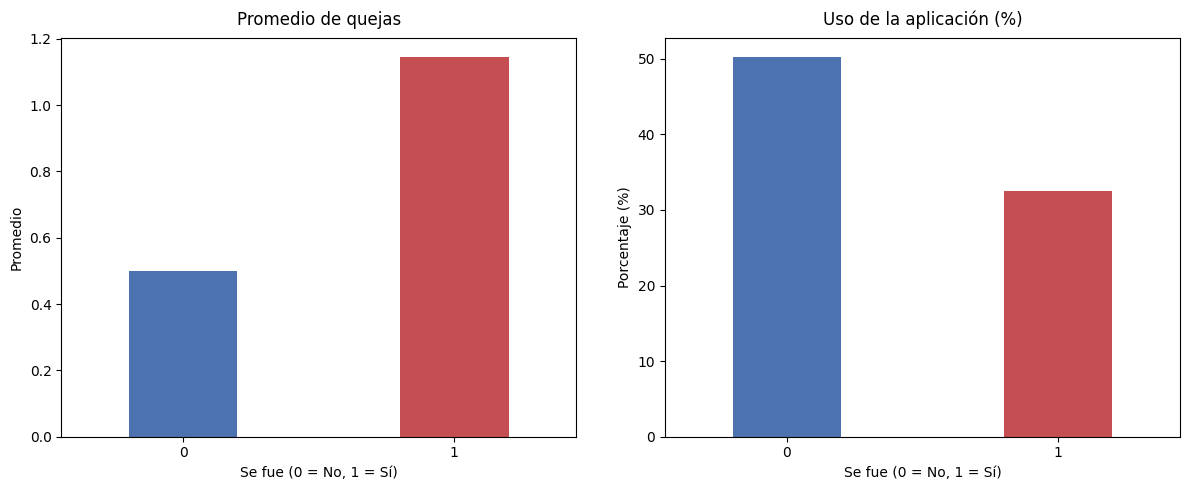


Caracteristicas de los segmentos:
          cantidad_clientes  recencia  frecuencia      monto  quejas  usa_app  \
Segmento                                                                        
0                       982     32.45        7.69  220571.08    0.42     0.40   
1                       313     10.40       24.74  908417.57    0.42     0.78   
2                       221    231.00        2.80   43147.96    1.14     0.37   
3                       484     67.97        2.79   54773.76    1.00     0.44   

          abandono  porcentaje_abandono  
Segmento                                 
0             0.10                 9.88  
1             0.01                 0.96  
2             0.86                85.52  
3             0.29                29.13  

Segmentos ordenados por abandono:
          cantidad_clientes  recencia  frecuencia      monto  quejas  usa_app  \
Segmento                                                                        
2                       221  

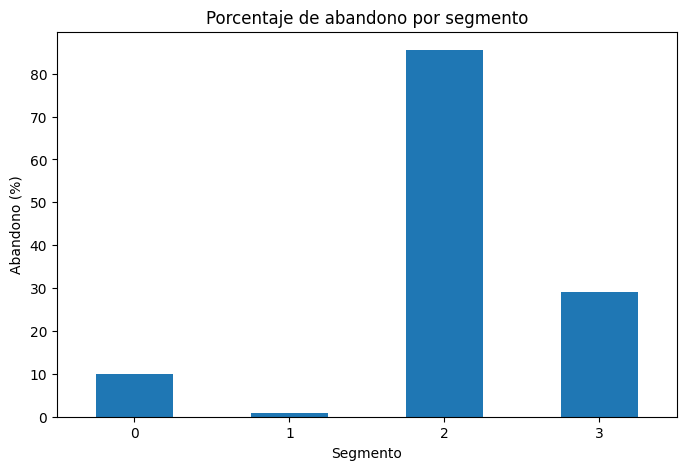


Modelos:
 

Datos de entrenamiento: (1600, 6)
Datos de prueba: (400, 6)

Regresion logistica:

Accuracy: 0.81
Precision: 0.545
Recall: 0.698
Matriz de confusion:
[[264  50]
 [ 26  60]]

Arbol de decision:

Accuracy: 0.86
Precision: 0.674
Recall: 0.674
Matriz de confusion:
[[286  28]
 [ 28  58]]


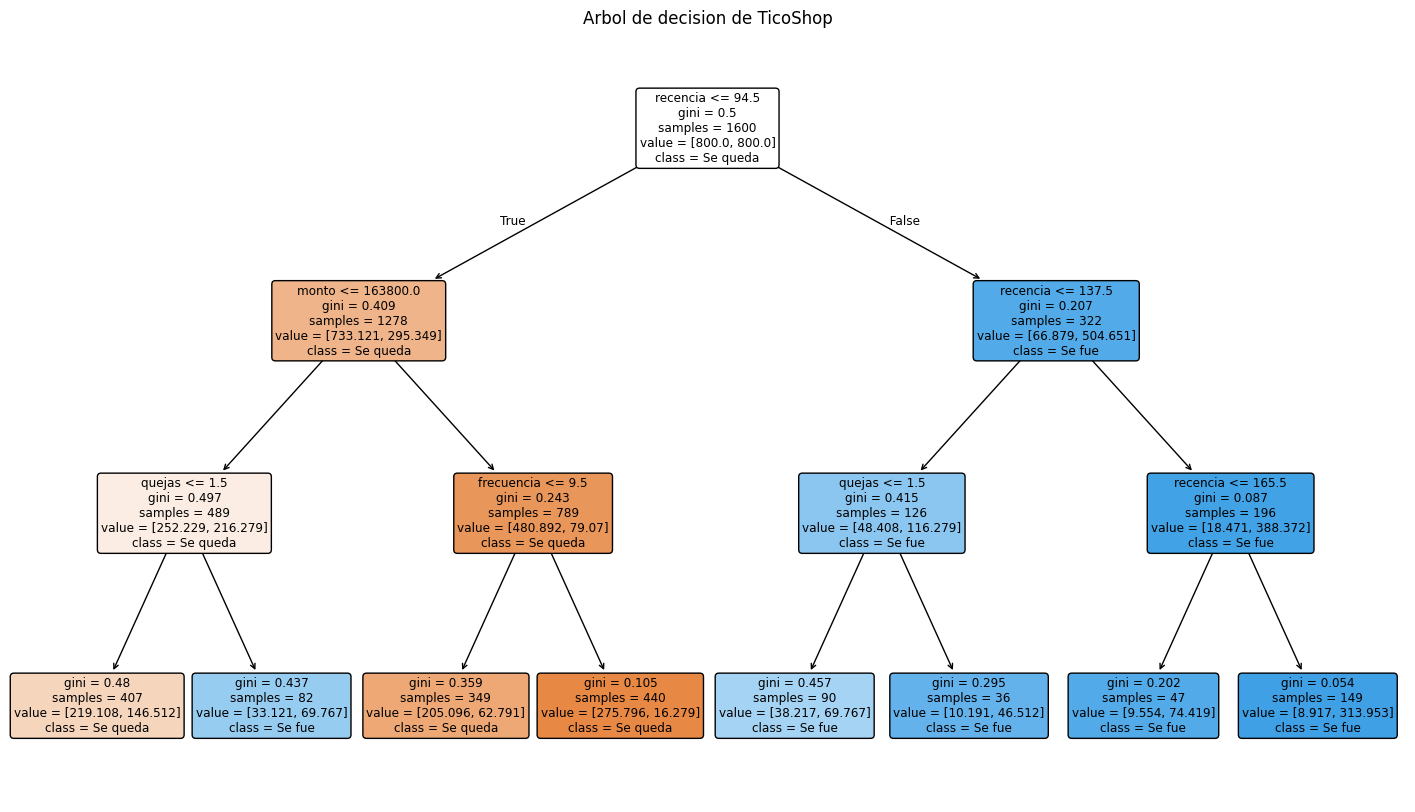


Comparacion de modelos:

                Modelo  Accuracy  Precision  Recall
0  Regresion logistica      0.81      0.545   0.698
1    Arbol de decision      0.86      0.674   0.674

Factores de riesgo:


Factores segun regresion logistica:
           Variable  Coeficiente                        Efecto
0          recencia        0.017    Aumenta el riesgo estimado
1        frecuencia       -0.150  Disminuye el riesgo estimado
2             monto       -0.000  Disminuye el riesgo estimado
3  antiguedad_meses       -0.002  Disminuye el riesgo estimado
4            quejas        0.475    Aumenta el riesgo estimado
5           usa_app       -0.691  Disminuye el riesgo estimado

Importancia de variables del arbol:
           Variable  Importancia
0          recencia        0.784
2             monto        0.149
4            quejas        0.041
1        frecuencia        0.025
3  antiguedad_meses        0.000
5           usa_app        0.000


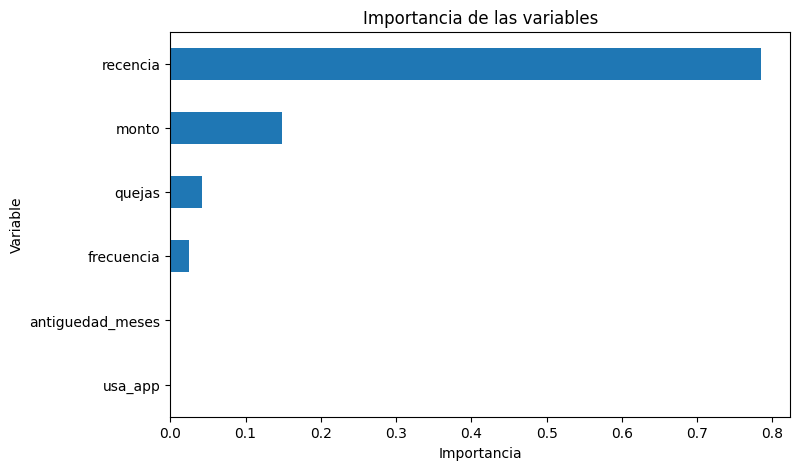


 Datos adicionales para el plan de accion de TicoShop:


Segmentos ordenados por porcentaje de abandono:
Segmento
2    85.52
3    29.13
0     9.88
1     0.96
Name: porcentaje_abandono, dtype: float64

Clientes prioritarios para contactar:
     cliente_id  Segmento  recencia  frecuencia  monto  quejas  usa_app
1073      C1074         2       365           3  64900       1        1
1770      C1771         2       365           6  69700       1        1
841       C0842         2       302           4  68000       0        1
629       C0630         2       255           4  67800       1        0
690       C0691         2       209           3  39600       0        0
451       C0452         2       208           3  40100       1        0
476       C0477         2       207           5  81700       0        1
656       C0657         2       204           2  26400       1        1
819       C0820         2       204           1  14800       1        0
765       C0766         2       198     

In [ ]:
#Examen Unidad 5 - TicoShop
#Keneth Josue Varela Ruiz

#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,confusion_matrix)

# Cargar los datos
archivo = files.upload()
nombre_archivo = list(archivo.keys())[0]

df = pd.read_excel(nombre_archivo, sheet_name="Clientes")

print("Archivo cargado correctamente")
print("Cantidad de clientes:", len(df))

###---------------------------Explorar los datos-----------------------------###

print("\nPrimeras filas:")
print(df.head())

print("\nClientes que se fueron y se quedaron:")
print(df["se_fue"].value_counts())

print("\nPorcentaje de abandono:")
print(df["se_fue"].value_counts(normalize=True) * 100)

#Comparacion de caracteristicas
variables = [ "recencia", "frecuencia", "monto","antiguedad_meses",
             "quejas", "usa_app"]

comparacion = df.groupby("se_fue")[variables].mean()

print("\nPromedios segun estado del cliente:")
print(comparacion)

#Graficos boxplot para ver el comportamiento de los clientes que se quedaron y los que se fueron
for variable in ["recencia", "frecuencia", "monto"]:
    plt.figure(figsize=(7, 5))
    df.boxplot(column=variable, by="se_fue")
    plt.title(f"{variable.capitalize()} segun estado del cliente")
    plt.suptitle("")
    plt.xlabel("Se fue (0 = No, 1 = Si)")
    plt.ylabel(variable.capitalize())
    plt.show()

#Graficos de barras para  quejas y uso de la aplicacion

#Figura para que los 2 graficos esten en la misma fila
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

datos = [("quejas", "Promedio de quejas", "Promedio"),
 ("usa_app", "Uso de la aplicación (%)", "Porcentaje (%)")]

for (variable, titulo, ylabel), ax in zip(datos, axes):
    valores = df.groupby("se_fue")[variable].mean()

    if variable == "usa_app":
        valores = valores * 100

    valores.plot(kind="bar", ax=ax, width=0.4, color=['#4C72B0', '#C44E52'])
    ax.set_title(titulo, fontsize=12, pad=10)
    ax.set_xlabel("Se fue (0 = No, 1 = Sí)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=0)

# Ajustar el espacio de los graficos
plt.tight_layout(w_pad=3.0)

plt.show()

###-----------------------Segmentacion de los datos--------------------------###

#Seleccionar variables para segmentar
variables_segmentacion = ["recencia", "frecuencia", "monto"]
X_segmentacion = df[variables_segmentacion].copy()

# Transformar variables con valores elevados
X_segmentacion["frecuencia"] = np.log1p(X_segmentacion["frecuencia"])
X_segmentacion["monto"] = np.log1p(X_segmentacion["monto"])

# Estandarizar los datos
scaler_cluster = StandardScaler()
X_escalado = scaler_cluster.fit_transform(X_segmentacion)

# Crear los segmentos
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

df["Segmento"] = kmeans.fit_predict(X_escalado)

# Caracteristicas de los segmentos
segmentos = df.groupby("Segmento").agg(cantidad_clientes=("cliente_id", "count"),
    recencia=("recencia", "mean"),frecuencia=("frecuencia", "mean"),
    monto=("monto", "mean"),quejas=("quejas", "mean"),
    usa_app=("usa_app", "mean"),abandono=("se_fue", "mean"))

segmentos["porcentaje_abandono"] = segmentos["abandono"] * 100

print("\nCaracteristicas de los segmentos:")
print(segmentos.round(2))

# Ordenar segmentos por abandono
print("\nSegmentos ordenados por abandono:")
print(segmentos.sort_values("porcentaje_abandono", ascending=False).round(2))

# Grafico de abandono por segmento
segmentos["porcentaje_abandono"].plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Porcentaje de abandono por segmento")
plt.xlabel("Segmento")
plt.ylabel("Abandono (%)")
plt.xticks(rotation=0)
plt.show()


###-----------------------------Modelos--------------------------------------###
print("\nModelos:\n ")

#Separar los datos para los modelos
# Seleccionar variables predictoras
X = df[[ "recencia", "frecuencia", "monto","antiguedad_meses","quejas",
        "usa_app"]]

y = df["se_fue"]

# Separar datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,
    random_state=42,stratify=y)

print("\nDatos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

## Regresion logistica ##

modelo_logistico = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)

modelo_logistico.fit(X_train, y_train)

y_pred_log = modelo_logistico.predict(X_test)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log, zero_division=0)
recall_log = recall_score(y_test, y_pred_log, zero_division=0)

print("\nRegresion logistica:\n")
print("Accuracy:", round(accuracy_log, 3))
print("Precision:", round(precision_log, 3))
print("Recall:", round(recall_log, 3))
print("Matriz de confusion:")
print(confusion_matrix(y_test, y_pred_log))


## Arbol de decision ##

modelo_arbol = DecisionTreeClassifier(max_depth=3,class_weight="balanced",random_state=42)

modelo_arbol.fit(X_train, y_train)

y_pred_arbol = modelo_arbol.predict(X_test)

accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
precision_arbol = precision_score(y_test, y_pred_arbol, zero_division=0)
recall_arbol = recall_score(y_test, y_pred_arbol, zero_division=0)

print("\nArbol de decision:\n")
print("Accuracy:", round(accuracy_arbol, 3))
print("Precision:", round(precision_arbol, 3))
print("Recall:", round(recall_arbol, 3))
print("Matriz de confusion:")
print(confusion_matrix(y_test, y_pred_arbol))

#Grafico del arbol
plt.figure(figsize=(18, 10))
plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=["Se queda", "Se fue"],
    filled=True,
    rounded=True
)
plt.title("Arbol de decision de TicoShop")
plt.show()

# Comparacion de modelos
resultados_modelos = pd.DataFrame({
    "Modelo": ["Regresion logistica", "Arbol de decision"],
    "Accuracy": [accuracy_log, accuracy_arbol],
    "Precision": [precision_log, precision_arbol],
    "Recall": [recall_log, recall_arbol]
})

print("\nComparacion de modelos:\n")
print(resultados_modelos.round(3))


#---------------------------Factores de riesgo----------------------------------

print("\nFactores de riesgo:\n")
## Coeficientes de la regresion logistica ##
coeficientes = pd.DataFrame({"Variable": X.columns,
"Coeficiente": modelo_logistico.coef_[0]})

#Determinar si la variable aumenta o disminuye el riego de que se vaya un cliente
coeficientes["Efecto"] = np.where(
    coeficientes["Coeficiente"] > 0,
    "Aumenta el riesgo estimado",
    "Disminuye el riesgo estimado"
)

coeficientes["Importancia"] = coeficientes["Coeficiente"].abs()

print("\nFactores segun regresion logistica:")
print(coeficientes[["Variable", "Coeficiente", "Efecto"]].round(3))

## Importancia de variables del arbol ##
importancias_arbol = pd.DataFrame({"Variable": X.columns,"Importancia":
                                   modelo_arbol.feature_importances_})

importancias_arbol = importancias_arbol.sort_values("Importancia",ascending=False)

print("\nImportancia de variables del arbol:")
print(importancias_arbol.round(3))

# Grafico de importancia
importancias_arbol.sort_values("Importancia").plot(
    x="Variable",
    y="Importancia",
    kind="barh",
    legend=False,
    figsize=(8, 5)
)
plt.title("Importancia de las variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


###-----------------Resultados para armar el plan de accion-------------------###

print("\n Datos adicionales para el plan de accion de TicoShop:\n")

# Seleccionar los clientes que aun siguen comprando
clientes_activos = df[df["se_fue"] == 0].copy()

# Identificar los segmentos con mayor abandono
abandono_segmentos = segmentos["porcentaje_abandono"].sort_values(ascending=False)

print("\nSegmentos ordenados por porcentaje de abandono:")
print(abandono_segmentos.round(2))

# Mostrar los clientes activos pertenecientes a los segmentos con mayor porcentaje de abandono
segmentos_prioritarios = abandono_segmentos.index[:2]

clientes_prioritarios = clientes_activos[clientes_activos["Segmento"].isin(segmentos_prioritarios)].copy()

# Ordenar primero por segmento de mayor abandono
clientes_prioritarios["orden_segmento"] = clientes_prioritarios["Segmento"].map
({segmentos_prioritarios[0]: 0,segmentos_prioritarios[1]: 1})

clientes_prioritarios = clientes_prioritarios.sort_values(["orden_segmento", "recencia", "quejas"],
                                                          ascending=[True, False, False])

print("\nClientes prioritarios para contactar:")
print(clientes_prioritarios[["cliente_id","Segmento","recencia","frecuencia",
                             "monto","quejas","usa_app"]].head(20))

# Resumen de las características de los clientes prioritarios
print("\nPromedio de características de los clientes prioritarios:")
print(clientes_prioritarios[["recencia", "frecuencia", "monto", "quejas", "usa_app"]
                            ].mean().round(2))

### 1. Análisis de los clientes

De los 2000 clientes analizados, 1570 permanecieron en TicoShop y 430 dejaron la empresa. Esto representa un 78.5% de clientes que permanecieron y un 21.5% de abandono.

Al comparar las características de los clientes, se observa que los clientes que se fueron tienen una recencia mucho mayor, realizan menos compras, gastan menos dinero y presentan más quejas. También utilizan menos la aplicación. Por otro lado, los clientes que permanecieron compran con mayor frecuencia, gastan más y han realizado compras más recientemente.

### 2. Segmentación de los Clientes

Los datos se segmentaron en 4 segmentos

El Segmento 0 (Clientes Activos) está formado por clientes que compran con cierta regularidad y mantienen un nivel importante de compras. Su porcentaje de abandono es de 9.88%, por lo que actualmente mantienen una relación relativamente estable con TicoShop.

El Segmento 1(Clientes Premium) está formado por clientes que compran con mucha frecuencia, realizan un gasto elevado y han comprado recientemente. Son los clienres que menos abandonan con porcentaje de 0.96%.

El Segmento 2(Clientes Alejados) son los clientes que llevan mucho tiempo sin comprar realizan pocas compras y presentan una mayor cantidad de quejas. Este grupo tiene el porcentaje de abandono más alto, con un 85.52%, por lo que necesita atención prioritaria.


El Segmento 3(Clientes en Riesgo) son los clientes que hacen pocas compras y llevan más tiempo sin comprar. Su porcentaje de abandono es de 29.13%, por lo que requieren atención para evitar que dejen la empresa.



### 3. Modelos de predicción

Se utilizaron una regresión logística y un árbol de decisión para predecir si un cliente se iría de TicoShop.

La regresión logística obtuvo un accuracy de 0.81, una precisión de 0.545 y un recall de 0.698. El árbol de decisión obtuvo un accuracy de 0.86, una precisión de 0.674 y un recall de 0.674.

El árbol de decisión obtuvo un mayor accuracy y una mayor precisión, mientras que la regresión logística obtuvo un recall ligeramente mayor. Esto significa que ambos modelos permiten identificar clientes con riesgo de abandono, aunque presentan diferencias en sus resultados.

### 4. Factores relacionados con el abandono

Los resultados muestran que la recencia es el factor más importante según el árbol de decisión. Los clientes que llevan más tiempo sin realizar una compra presentan un mayor riesgo de abandono.

También se observa que una mayor cantidad de quejas está relacionada con un mayor riesgo de abandono. Por otro lado, una mayor frecuencia de compra y el uso de la aplicación están relacionados con una menor probabilidad estimada de abandono.

### 5. Plan de acción para la gerente de mercadeo

TicoShop deberia empezar por contactarlos Clientes Alejados (Segmento 2) que todavía siguen comprando porque son los clientes que llevan más tiempo sin realizar una compra y presentan el mayor porcentaje de abandono. Se les pueden ofrecer promociones o beneficios especiales para motivarlos a volver a comprar.
Después se debe contactar a los Clientes en Riesgo (Segmento 3), ya que también han reducido su actividad y presentan un mayor porcentaje de abandono. Para ellos se pueden enviar promociones relacionadas con sus compras anteriores o beneficios que los motiven a realizar una nueva compra, a la vez tomar en consideracion las quejas seria util para determinar si es posible una solucion o si se repite un patron en las quejas arreglarlo inmediatamente

Finalmente, se debe mantener una buena comunicación con los Clientes Activos y Clientes Premium, especialmente con quienes compran con mayor frecuencia. Con el fin de mantener una base de clientes fieles

De esta manera, TicoShop puede concentrar primero sus esfuerzos en los clientes que muestran mayores señales de alejamiento y, al mismo tiempo, mantener una buena relación con los clientes que continúan comprando con frecuencia.
